# Lab 05: Hybrid Physics-AI: Residual-Gated Proposals & Solver Correction

**Learning Objective:** Implement a hybrid solver loop where a fast neural network proposes a trial solution, an admissibility gate evaluates the physical residual, and a trusted numerical solver corrects or refines the state when needed.

<div class="badge-row">
  <a class="badge-colab" href="https://colab.research.google.com/github/CEMS-Lab/autumn-school/blob/main/notebooks/study/05_hybrid_reference_correction.ipynb" target="_blank"><img src="../_static/colab-badge.svg" alt="Open In Colab"/></a>
  <a class="badge-link" href="../../notebooks/study/05_hybrid_reference_correction.ipynb"><i class="fa-solid fa-download"></i> Download Practice Notebook</a>
  <a class="badge-link" href="../../notebooks/solutions/05_hybrid_reference_correction.ipynb"><i class="fa-solid fa-check-circle"></i> Download with Worked Solutions</a>
  <a class="badge-link" href="../../SETUP.md"><i class="fa-solid fa-gear"></i> Environment Setup</a>
</div>

In safety-critical engineering mechanics, purely data-driven neural networks can produce inaccurate predictions when queried outside their training distribution. A hybrid solver architecture combines the speed of learned models with the reliability of numerical solvers:
1. **Fast Neural Proposal:** The neural network generates an initial trial field $\widehat{u}$.
2. **Physics-Based Gating:** The physical PDE residual $r = \|R(\widehat{u})\|$ is evaluated.
3. **Selective Solver Refinement:** If the residual is below tolerance, the proposal is accepted; otherwise, the proposal serves as an initial guess for a reference numerical solver, accelerating convergence.


In [1]:
# Google Colab environment setup
try:
    import google.colab
    import subprocess
    from pathlib import Path
    if not Path("autumn-school").is_dir() and not Path("notebooks").is_dir():
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/CEMS-Lab/autumn-school.git"], check=True)
except ImportError:
    pass

from pathlib import Path
import sys

def locate_course_root():
    for base in (Path.cwd(), *Path.cwd().parents, Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()):
        direct = base / "teaching" / "ukacm_autumn_school_2026"
        if (direct / "notebooks" / "day2_helpers").is_dir():
            return direct
        if (base / "notebooks" / "day2_helpers").is_dir():
            return base
        if (base / "autumn-school" / "notebooks" / "day2_helpers").is_dir():
            return base / "autumn-school"
    raise FileNotFoundError("Could not find teaching/ukacm_autumn_school_2026.")

COURSE_ROOT = locate_course_root()
if str(COURSE_ROOT / "notebooks") not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT / "notebooks"))

import matplotlib.pyplot as plt
import numpy as np
import torch
from io import BytesIO
from IPython.display import Image, display

from day2_helpers import assets_dir

torch.set_default_dtype(torch.float64)

def display_figure(figure, dpi=150, alt="Rendered teaching figure"):
    """Embed a PNG even when nbclient uses a non-interactive Agg backend."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    display(Image(data=buffer.getvalue(), alt=alt))

print({"course_layout": "teaching/ukacm_autumn_school_2026 located", "torch": torch.__version__, "device": "cpu", "dtype": str(torch.get_default_dtype())})


{'course_layout': 'teaching/ukacm_autumn_school_2026 located', 'torch': '2.8.0', 'device': 'cpu', 'dtype': 'torch.float64'}


In [2]:
import json
from day2_helpers.course_tools import (
    FEATURE_ORDER, ToyDamageAdapter, ToyHelmholtzProblem,
    load_toy_model, make_toy_checkpoint,
)

checkpoint_path = assets_dir() / "models" / "tiny_damage_mlp.pt"
if not checkpoint_path.exists():
    # This makes the notebook independently executable. In the normal
    # sequence notebook 04 has already produced this exact artifact.
    make_toy_checkpoint(checkpoint_path, epochs=400, force=True)
model, metadata = load_toy_model(checkpoint_path)
problem = ToyHelmholtzProblem()
adapter = ToyDamageAdapter(model, metadata, problem)
print({"interface_version": metadata["interface_version"], "feature_order": metadata["feature_order"], "mesh_signature": metadata["mesh_signature"]})


{'interface_version': 'ukacm-toy-damage-v1', 'feature_order': ['x_over_L', 'y_over_H', 'load_factor'], 'mesh_signature': [25, 13]}


In [3]:
# Compatible held-out request. d_previous comes from a lower-load state.
load_factor = 0.94
d_previous = problem.reference_field(0.82)
proposal = adapter.propose(problem.features(load_factor), d_previous=d_previous)
assessment = adapter.assess(proposal, load_factor, residual_limit=0.30)
reference = problem.reference_field(load_factor)
corrected = proposal if assessment["accepted"] else adapter.fallback(load_factor, d_previous)
print({"normal_proposal": assessment, "field_rmse": float(torch.sqrt(torch.mean((proposal-reference)**2)))})
assert assessment["accepted"], assessment

# A deliberately corrupted field is projected but fails the same residual gate.
corrupted = torch.where(
    problem.boundary_mask,
    torch.zeros_like(proposal),
    (proposal + 0.30 * torch.sin(12 * problem.coordinates[:, 0])).clamp(0, 1),
)
rejected = adapter.assess(corrupted, load_factor, residual_limit=0.30)
fallback = adapter.fallback(load_factor, d_previous)
print({"corrupted_proposal": rejected, "fallback_residual": problem.relative_residual(fallback, load_factor)})
assert not rejected["accepted"], rejected
assert problem.relative_residual(fallback, load_factor) < 1.0e-10


{'normal_proposal': {'toy_relative_residual': 0.19402747874051113, 'residual_limit': 0.3, 'accepted': True, 'scope': 'Residual of the discrete ToyHelmholtzProblem'}, 'field_rmse': 0.029164814588982523}
{'corrupted_proposal': {'toy_relative_residual': 1.164008876432137, 'residual_limit': 0.3, 'accepted': False, 'scope': 'Residual of the discrete ToyHelmholtzProblem'}, 'fallback_residual': 2.969565304912253e-15}


In [4]:
# Explicitly demonstrate an interface failure instead of silently reshaping input.
try:
    adapter.propose(
        problem.features(load_factor),
        feature_order=("load_factor", "x_over_L", "y_over_H"),
    )
except ValueError as error:
    compatibility_message = str(error)
else:
    raise AssertionError("An incompatible feature order was unexpectedly accepted.")
print("Expected incompatibility:", compatibility_message)

nan_features = problem.features(load_factor).clone()
nan_features[0, 0] = float("nan")
try:
    adapter.propose(nan_features)
except ValueError as error:
    finiteness_message = str(error)
else:
    raise AssertionError("A non-finite adapter input was unexpectedly accepted.")
print("Expected finite-input rejection:", finiteness_message)


Expected incompatibility: Incompatible feature order. Expected ['x_over_L', 'y_over_H', 'load_factor'], got ['load_factor', 'x_over_L', 'y_over_H'].
Expected finite-input rejection: Incompatible feature tensor: all adapter inputs must be finite.


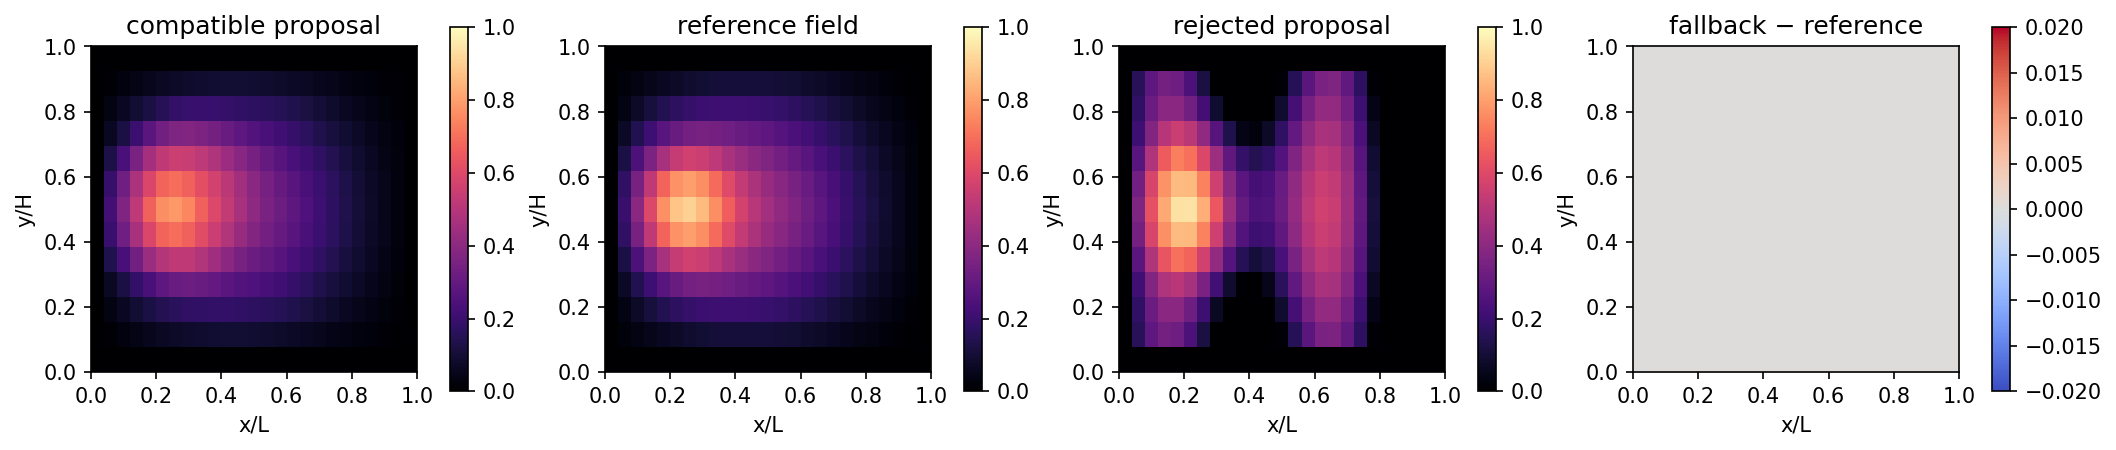

In [5]:
def field_image(values):
    return values.detach().reshape(problem.ny, problem.nx).cpu().numpy()

fig, axes = plt.subplots(1, 4, figsize=(14, 3.2), constrained_layout=True)
panels = (
    (proposal, "compatible proposal", "magma", (0, 1)),
    (reference, "reference field", "magma", (0, 1)),
    (corrupted, "rejected proposal", "magma", (0, 1)),
    (fallback - reference, "fallback − reference", "coolwarm", (-0.02, 0.02)),
)
for ax, field, title, cmap, limits in zip(axes, *zip(*panels)):
    image = ax.imshow(field_image(field), origin="lower", extent=(0,1,0,1), cmap=cmap, vmin=limits[0], vmax=limits[1])
    ax.set(title=title, xlabel="x/L", ylabel="y/H", aspect="equal")
    fig.colorbar(image, ax=ax, shrink=0.78)
fig.savefig(assets_dir() / "toy_adapter_fallback.png", dpi=160, bbox_inches="tight")
display_figure(fig, alt="Toy adapter's compatible proposal, reference, rejected proposal, and fallback error.")
plt.close(fig)


In [6]:
# Save one proposal/reference pair for an offline replay dataset.
# Include reference-label cost in a later retraining comparison.
replay_record = {
    "scope": "course-owned ToyHelmholtzProblem; one offline proposal/reference correction record",
    "load_factor": load_factor,
    "feature_order": list(FEATURE_ORDER),
    "normal_assessment": assessment,
    "rejected_assessment": rejected,
    "correction": "classical ToyHelmholtzProblem reference solve",
    "heldout_evaluation_frozen": True,
}
replay_path = assets_dir() / "toy_adapter_replay_record.json"
replay_path.write_text(json.dumps(replay_record, indent=2), encoding="utf-8")
print({"replay_record": str(replay_path.relative_to(COURSE_ROOT)), "decision": "accept compatible / fallback rejected"})


{'replay_record': 'assets/day2_forward/toy_adapter_replay_record.json', 'decision': 'accept compatible / fallback rejected'}


The saved correction record pairs a model proposal with its reference
solution. An offline DAgger extension uses such records in a repeated
cycle: collect states visited by the current model, obtain reference
labels, add those cases to the training data, retrain, and evaluate
on a fixed held-out set. Include the cost of reference solves when
assessing the computational benefit of that cycle.


## Exercises

Try each question before opening the hint or worked solution. Keep the original calculation as your reference.

### Exercise 1: Make the residual-gate decision

At load factor $0.94$, the compatible proposal has relative residual $0.1940274787$ and the deliberately corrupted proposal has relative residual $1.1640088764$. The acceptance limit is $0.30$. The reference fallback has residual $2.9696\times10^{-15}$.

1. Decide accept or reject for each proposal.
2. Compute the compatible proposal's margin below the limit and the corrupted proposal's excess above it.
3. Explain why the reference result is still needed after a rejection.

::::{admonition} Hint 1
:class: dropdown course-hint

The adapter accepts only when residual $\le0.30$. Subtract in the direction that produces a positive margin or excess.
::::

::::{admonition} Worked solution 1
:class: dropdown course-solution

1. The compatible proposal is accepted because

$$
0.1940274787\le0.30.
$$

The corrupted proposal is rejected because

$$
1.1640088764>0.30.
$$

2. The accepted proposal's margin is

$$
0.30-0.1940274787=0.1059725213,
$$

whereas the corrupted proposal exceeds the limit by

$$
1.1640088764-0.30=0.8640088764.
$$

3. On rejection, the adapter invokes the classical ToyHelmholtz reference solve, whose residual is near machine precision. This replaces an inaccurate proposal with a solution of the discrete model equation. The acceptance threshold is an illustrative choice for this exercise; select a tolerance appropriate to the observable and discretisation in an application.
::::

### Exercise 2: Project a field and extend the correction cycle

For an interior node, the adapter first clamps a raw proposal to $[0,1]$ and then applies irreversibility with $\max(d_{\mathrm{proposal}},d_{\mathrm{previous}})$. Finally it enforces zero on the ToyHelmholtz boundary.

1. Compute the final value for each case: (a) raw $0.15$, previous $0.25$, interior; (b) raw $1.4$, previous $0.25$, interior; (c) raw $0.7$, previous $0.25$, boundary.
2. Name two interface checks that must happen before this projection.
3. The notebook saves one correction record. Describe how to use such records in an offline DAgger extension.

::::{admonition} Hint 2
:class: dropdown course-hint

Apply the operations in order. The boundary rule is last, so it overrides an otherwise admissible projected value.
::::

::::{admonition} Worked solution 2
:class: dropdown course-solution

1. (a) Clamp leaves $0.15$, irreversibility gives $\max(0.15,0.25)=0.25$, and the node is interior, so the final value is $0.25$. (b) Clamp maps $1.4$ to $1$, then $\max(1,0.25)=1$, so the final value is $1$. (c) The interior-style projection would be $0.7$, but the boundary rule is applied last, so the final value is $0$.

2. The adapter checks that all feature values are finite, that feature order is exactly $[x/L,y/H,\mathrm{load\ factor}]$, that the mesh signature matches $[25,13]$, and that the feature tensor shape is compatible. A feature-order mismatch or a NaN triggers rejection.

3. Begin with the saved proposal/reference pair. To form an offline DAgger cycle, collect states visited by the current model over a defined rollout, obtain reference labels, add the labelled cases to the training data, retrain, and assess a fixed held-out set. Account for the cost of reference labels. In the present exercise the model weights remain fixed during inference under **torch.no_grad()**, and the residual comes from the ToyHelmholtz equation.
::::